# 3.4 PyTorch 학습 루프 표준 패턴 — 실습

**작성일:** 2026-04-24
**이론 문서:** `04_PyTorch_학습루프.md`
**데이터:** `../../black_litterman/data/panels/MSFT.csv` (MSFT 일별 수익률)
**선행:** 3.3 (GRU), 3.2 (LSTM), 2.5 (tensor dimensions)
**후속:** 3.5 (학습 안정화 + 정규화)

---

## 이 노트북의 목표

이론에서 배운 학습 루프의 **모든 구성요소**를 실제 코드로 재현하고, "왜 이 코드가 필요한가" 를 **일부러 빼고 돌려서 망가지는 모습**을 눈으로 확인합니다.

### 검증 맵 (이론 §n → 이 노트북 §n)

| 이론 §  | 주제                              | 실습 §  | 검증 방식 |
|--------|----------------------------------|---------|---------|
| §1~§8   | 표준 학습 사이클                   | §3       | 정상 학습 → train/val loss 곡선 감소 확인 |
| §11·§12 | AdamW + Gradient Clipping         | §5       | clip 유무 2조건 비교 → NaN 발생 재현 |
| §13     | LR Scheduler                      | §6       | StepLR / Cosine / ReduceLROnPlateau 3종 비교 |
| §18.1   | 흔한 실수 (zero_grad, eval)       | §4       | 의도적 버그 주입 → loss 폭주/진동 관찰 |
| §16     | 경량 학습 반복 함수                | §7       | `train_one_individual(params)` 구현 + 5회 호출 |
| §10     | Loss 함수 (MSE/Huber)             | §8       | outlier 주입 조건에서 robust 비교 |

### 과제 정의

- **입력**: MSFT 일별 log-return 의 과거 60일 윈도우 (shape `[B, 60, 1]`)
- **출력**: 다음날 log-return 예측 **(스칼라 회귀)** — COL-BL 과 동일 구조
- **Loss**: `nn.MSELoss()` (§8 에서 `nn.HuberLoss()` 와 비교)
- **이론 예제(§10)는 CrossEntropy 기반이었으나, 실습은 COL-BL 일관성을 위해 회귀로 전환** — 학습 루프 골격은 동일함을 이 노트북에서 직접 확인

## §0. 환경 준비

- 시드 고정 (재현성 — 이론 §16.5)
- device 결정 (GPU 있으면 cuda)
- 한글 폰트 (프로젝트 CLAUDE.md 지침)

In [1]:
# ---------------------------------------------------------------------
# 기본 라이브러리 import
# ---------------------------------------------------------------------
import os
import math
import random
import warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Callable

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

import matplotlib.pyplot as plt
import platform

# ---------------------------------------------------------------------
# 한글 폰트 (OS 분기 — CLAUDE.md 지침)
# ---------------------------------------------------------------------
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux (샌드박스 등)
    try:
        import koreanize_matplotlib  # noqa: F401
    except ModuleNotFoundError:
        # 미설치 시: pip install koreanize-matplotlib --break-system-packages
        plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

warnings.filterwarnings('ignore', category=UserWarning)

# ---------------------------------------------------------------------
# 재현성 — 이론 §16.5
# 같은 hyperparam 이 같은 결과를 내야 §7 비교가 공정합니다.
# ---------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# cuDNN 재현성 (속도 약간 희생, 결정성 확보)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')
print(f'torch : {torch.__version__}')

device: cuda
torch : 2.11.0+cu126


## §1. 데이터 로딩 & sliding window

MSFT 일별 수익률 (`log_return_1d`) 을 불러와 **과거 60일 → 다음 1일** 회귀 문제로 변환합니다.

### 분할 규칙
시계열 데이터는 **반드시 시간순 분할** (shuffle 금지 — 2.3 look-ahead bias 참조):
- Train: ~2018-12-31
- Val  : 2019-01-01 ~ 2020-12-31
- Test : 2021-01-01 이후

### 왜 수익률을 쓰는가
가격(price)은 비정상 시계열이라 직접 예측하면 스케일 문제·트렌드 편향이 생깁니다. 수익률은 **정상성에 가까워** 학습이 안정적입니다.

In [2]:
# ---------------------------------------------------------------------
# MSFT.csv 로드
# ---------------------------------------------------------------------
DATA_PATH = Path('../../black_litterman/data/panels/MSFT.csv')
df = pd.read_csv(DATA_PATH, parse_dates=['date'])

# 첫 행은 수익률이 NaN (이전 날짜가 없음) — 보수적으로 dropna
df = df[['date', 'log_return_1d']].dropna().reset_index(drop=True)

print(f'전체 기간  : {df["date"].min().date()} ~ {df["date"].max().date()}')
print(f'전체 일수  : {len(df):,}')
print(f'수익률 평균: {df["log_return_1d"].mean():.6f}')
print(f'수익률 표준편차: {df["log_return_1d"].std():.6f}')
df.head()

전체 기간  : 2010-01-05 ~ 2025-12-30
전체 일수  : 4,022
수익률 평균: 0.000758
수익률 표준편차: 0.016053


,date,log_return_1d
0,2010-01-05,0.000323
1,2010-01-06,-0.006156
2,2010-01-07,-0.010454
3,2010-01-08,0.006873
4,2010-01-11,-0.012802


In [3]:
# ---------------------------------------------------------------------
# Sliding window → [N_samples, WINDOW, 1] 회귀 데이터셋
# ---------------------------------------------------------------------
WINDOW = 60          # 과거 60거래일
HORIZON = 1          # 다음날 수익률 예측
FEATURE_DIM = 1      # log_return 단변량

returns = df['log_return_1d'].to_numpy(dtype=np.float32)
dates = df['date'].to_numpy()

def make_windows(arr: np.ndarray, window: int, horizon: int):
    """arr 에서 [window → horizon] 회귀 샘플 생성.
    X[i] = arr[i : i+window]      → shape (window,)
    y[i] = arr[i+window+horizon-1] → shape ()
    """
    N = len(arr) - window - horizon + 1
    X = np.zeros((N, window), dtype=np.float32)
    y = np.zeros((N,),         dtype=np.float32)
    for i in range(N):
        X[i] = arr[i : i + window]
        y[i] = arr[i + window + horizon - 1]
    # LSTM 입력 형태 [N, T, F] 로 reshape
    return X[:, :, None], y

X_all, y_all = make_windows(returns, WINDOW, HORIZON)
dates_target = dates[WINDOW + HORIZON - 1 :]   # y 각 샘플의 타겟 날짜

print(f'X shape: {X_all.shape}   (N, T, F)')
print(f'y shape: {y_all.shape}   (N,)')
print(f'타겟 날짜 범위: {pd.Timestamp(dates_target[0]).date()} ~ {pd.Timestamp(dates_target[-1]).date()}')

X shape: (3962, 60, 1)   (N, T, F)
y shape: (3962,)   (N,)
타겟 날짜 범위: 2010-04-01 ~ 2025-12-30


In [4]:
# ---------------------------------------------------------------------
# 시간순 분할 — train / val / test
# ---------------------------------------------------------------------
def idx_of(date_str: str) -> int:
    """특정 날짜 기준으로 인덱스 반환 (경계는 해당 날짜 포함 직전)."""
    return int(np.searchsorted(dates_target, np.datetime64(date_str)))

train_end = idx_of('2019-01-01')      # train: [0, train_end)
val_end   = idx_of('2021-01-01')      # val  : [train_end, val_end)
# test: [val_end, end)

X_train, y_train = X_all[:train_end], y_all[:train_end]
X_val,   y_val   = X_all[train_end:val_end], y_all[train_end:val_end]
X_test,  y_test  = X_all[val_end:],          y_all[val_end:]

# 각 split 의 타겟 날짜 범위를 계산 (시각적 확인용)
splits = {
    'train': (0,         train_end),
    'val'  : (train_end, val_end),
    'test' : (val_end,   len(y_all)),
}
for name, (lo, hi) in splits.items():
    start_date = pd.Timestamp(dates_target[lo]).date()
    end_date   = pd.Timestamp(dates_target[hi - 1]).date()
    y_slice = y_all[lo:hi]
    print(f'{name:<6} | {hi - lo:>4} samples  | {start_date} ~ {end_date}  '
          f'| y 평균 {y_slice.mean():+.5f}  표준편차 {y_slice.std():.5f}')

train  | 2203 samples  | 2010-04-01 ~ 2018-12-31  | y 평균 +0.00066  표준편차 0.01455
val    |  505 samples  | 2019-01-02 ~ 2020-12-31  | y 평균 +0.00160  표준편차 0.02146
test   | 1254 samples  | 2021-01-04 ~ 2025-12-30  | y 평균 +0.00066  표준편차 0.01617


In [5]:
# ---------------------------------------------------------------------
# PyTorch DataLoader 구성
# ---------------------------------------------------------------------
BATCH_SIZE = 64

def make_loader(X: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool):
    """numpy → tensor → DataLoader. seed 통제된 generator 로 재현성 확보."""
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    g = torch.Generator().manual_seed(SEED)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, generator=g)

# train 은 shuffle=True 여도 *시간순 분할이 이미 끝난 뒤* 의 배치 셔플이라 누수 없음
train_loader = make_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   BATCH_SIZE, shuffle=False)
test_loader  = make_loader(X_test,  y_test,  BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print(f'batch X: {xb.shape}  (B, T, F)')
print(f'batch y: {yb.shape}  (B,)')
print(f'dtype  : {xb.dtype}')

batch X: torch.Size([64, 60, 1])  (B, T, F)
batch y: torch.Size([64])  (B,)
dtype  : torch.float32


## §2. LSTM 회귀 모델 빌드 — 이론 §3~§4 와 §18 표준 템플릿

이론 §18 의 `MyLSTMClassifier` (분류) 를 **회귀로 전환**.

### 변경점 (분류 → 회귀)
| 구성요소 | 분류 (이론 §18) | 회귀 (이 실습, COL-BL) |
|---|---|---|
| 마지막 Linear 차원 | `(H, num_classes)` | **`(H, 1)`** |
| forward 출력 | logits `[B, C]` | **스칼라 `[B]`** |
| Loss | `nn.CrossEntropyLoss` | **`nn.MSELoss`** |
| 메트릭 | Accuracy | **MSE, RMSE** (그리고 §8 에서 방향성 정확도) |

**학습 루프 골격은 동일** — criterion 과 마지막 Linear 만 바뀌면 됩니다.

In [6]:
class LSTMRegressor(nn.Module):
    """COL-BL 의 per-IMF LSTM 에 해당하는 구조.
    [B, T, F] → (LSTM H_T) → Linear → 스칼라 수익률 예측.
    """
    def __init__(self,
                 input_size: int = 1,
                 hidden_size: int = 64,
                 num_layers: int = 1,
                 dropout: float = 0.0):
        super().__init__()
        self.hidden_size = hidden_size
        # dropout 은 num_layers >= 2 일 때만 PyTorch LSTM 내부에서 적용됨
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)  # 회귀 — 스칼라 1개

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, T, F]
        out, (h_T, c_T) = self.lstm(x)   # h_T: [num_layers, B, H]
        last = h_T[-1]                    # 마지막 층의 hidden state : [B, H]
        pred = self.head(last).squeeze(-1)  # [B]
        return pred


# 파라미터 수 확인
model = LSTMRegressor(input_size=1, hidden_size=64, num_layers=1, dropout=0.0).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'LSTMRegressor (H=64, 1-layer) parameter count: {n_params:,}')
print(model)

LSTMRegressor (H=64, 1-layer) parameter count: 17,217
LSTMRegressor(
  (lstm): LSTM(1, 64, batch_first=True)
  (head): Linear(in_features=64, out_features=1, bias=True)
)


## §3. 표준 학습 루프 실행 — 이론 §17 템플릿 재현

이론의 **표준 템플릿 전체** (AdamW + Gradient Clipping + ReduceLROnPlateau + Checkpoint best-val) 를 적용해 한 번 학습시킵니다. 이후 §4~§8 에서 이 결과를 "정상 조건" 으로 두고 비교합니다.

In [7]:
# ---------------------------------------------------------------------
# 표준 학습 루프 — 이론 §17 템플릿
# ---------------------------------------------------------------------
def train_standard(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    *,
    max_epochs: int = 30,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    clip_grad: float | None = 1.0,       # None 이면 clipping off (§5 에서 비교)
    scheduler_kind: str = 'plateau',     # 'none' | 'step' | 'cosine' | 'plateau'
    early_stop_patience: int | None = None,
    skip_zero_grad: bool = False,        # §4 — True 면 일부러 누락
    skip_eval_mode: bool = False,        # §4 — True 면 model.eval() 생략
    verbose: bool = True,
):
    """회귀용 표준 학습 루프. 히스토리 dict 반환.
    §4, §5, §6 실험을 위해 스위치들을 파라미터로 노출.
    """
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Scheduler 분기 — 이론 §13
    if scheduler_kind == 'step':
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    elif scheduler_kind == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
    elif scheduler_kind == 'plateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3)
    else:
        scheduler = None

    history = {'train_loss': [], 'val_loss': [], 'lr': []}
    best_val = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(1, max_epochs + 1):
        # ------------- train -------------
        model.train()
        running = 0.0
        n_seen = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            if not skip_zero_grad:
                optimizer.zero_grad()            # ← §4 에서 일부러 빼봄

            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()

            if clip_grad is not None:
                # 이론 §12 — 시퀀스 모델의 안전장치
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad)

            optimizer.step()
            running += loss.item() * xb.size(0)
            n_seen  += xb.size(0)
        train_loss = running / n_seen

        # ------------- validate -------------
        if not skip_eval_mode:
            model.eval()                          # ← §4 에서 일부러 빼봄
        val_running = 0.0
        val_n = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                val_running += criterion(pred, yb).item() * xb.size(0)
                val_n += xb.size(0)
        val_loss = val_running / val_n

        # ------------- scheduler -------------
        if scheduler is not None:
            if scheduler_kind == 'plateau':
                scheduler.step(val_loss)
            else:
                scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # ------------- checkpoint (best val) -------------
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(current_lr)

        if verbose and (epoch == 1 or epoch % 5 == 0 or epoch == max_epochs):
            print(f'[epoch {epoch:3d}] train {train_loss:.6f} | val {val_loss:.6f} | lr {current_lr:.2e}')

        # ------------- early stopping -------------
        if early_stop_patience is not None and patience_counter >= early_stop_patience:
            if verbose:
                print(f'▲ early stop at epoch {epoch} (val not improving for {early_stop_patience} epochs)')
            break

    return history, best_val, best_state

In [8]:
# ---------------------------------------------------------------------
# 정상 조건으로 한 번 학습 — §3 baseline
# ---------------------------------------------------------------------
torch.manual_seed(SEED)   # 모델 가중치 초기화 재현
model_std = LSTMRegressor(input_size=1, hidden_size=64, num_layers=1, dropout=0.0).to(device)

hist_std, best_val_std, _ = train_standard(
    model_std, train_loader, val_loader, device,
    max_epochs=30, lr=1e-3, weight_decay=1e-4,
    clip_grad=1.0, scheduler_kind='plateau',
    early_stop_patience=None,   # §3 에서는 full 30 epoch
)
print(f'\n최종 best val MSE: {best_val_std:.6f}')

[epoch   1] train 0.000577 | val 0.000490 | lr 1.00e-03
[epoch   5] train 0.000214 | val 0.000456 | lr 1.00e-03
[epoch  10] train 0.000214 | val 0.000458 | lr 5.00e-04
[epoch  15] train 0.000216 | val 0.000458 | lr 5.00e-04
[epoch  20] train 0.000212 | val 0.000453 | lr 5.00e-04
[epoch  25] train 0.000214 | val 0.000460 | lr 2.50e-04
[epoch  30] train 0.000214 | val 0.000456 | lr 1.25e-04

최종 best val MSE: 0.000452


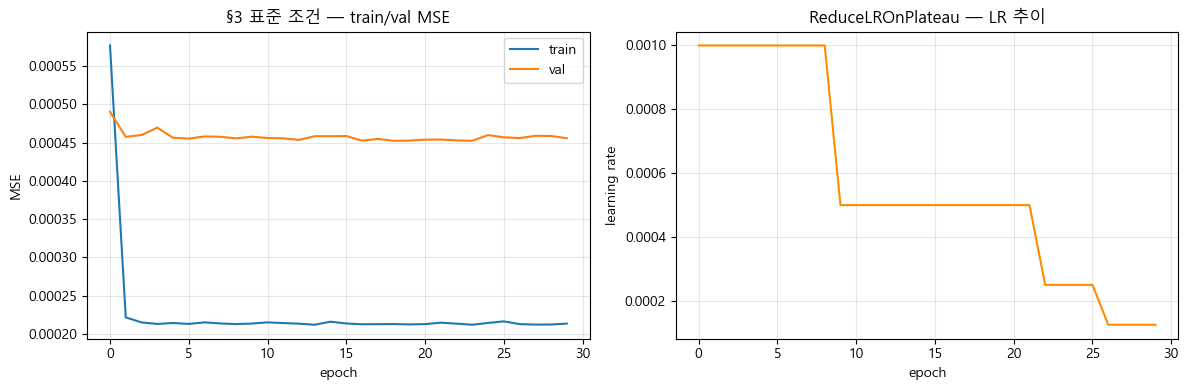

In [9]:
# ---------------------------------------------------------------------
# 학습 곡선 시각화
# ---------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist_std['train_loss'], label='train')
ax1.plot(hist_std['val_loss'],   label='val')
ax1.set_xlabel('epoch'); ax1.set_ylabel('MSE')
ax1.set_title('§3 표준 조건 — train/val MSE')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(hist_std['lr'], color='darkorange')
ax2.set_xlabel('epoch'); ax2.set_ylabel('learning rate')
ax2.set_title('ReduceLROnPlateau — LR 추이')
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §4. 흔한 실수 의도적 재현 — 이론 §18.1

이론 문서에서 "절대 하면 안 되는 것" 으로 언급한 실수 2개를 **일부러 실행**해 결과가 어떻게 망가지는지 관찰합니다. 이런 실수는 실무에서 **조용히 잘못된 모델을 만들기 때문에** — 학습은 돌아가지만 성능이 이상하게 나옵니다.

### 실험 설계
1. **실수 A — `optimizer.zero_grad()` 누락**: gradient 가 누적되어 파라미터 업데이트 방향이 왜곡
2. **실수 B — `model.eval()` 누락**: 검증 중에도 dropout/BN 랜덤이 켜져 val_loss 가 들쭉날쭉

### 주의
아래 실험은 이해를 돕기 위한 의도적 오남용입니다. 실무 코드에는 **절대 이런 식으로 작성하지 마세요**.

In [10]:
# ---------------------------------------------------------------------
# 실수 A: zero_grad 누락
# ---------------------------------------------------------------------
torch.manual_seed(SEED)
model_skip_zero = LSTMRegressor(1, 64, 1, 0.0).to(device)
hist_skip_zero, best_skip_zero, _ = train_standard(
    model_skip_zero, train_loader, val_loader, device,
    max_epochs=15, lr=1e-3, weight_decay=1e-4,
    clip_grad=1.0, scheduler_kind='none',
    skip_zero_grad=True, verbose=False,
)
print(f'zero_grad 누락: best val MSE = {best_skip_zero:.6f}')

# ---------------------------------------------------------------------
# 실수 B: eval 모드 누락 (dropout 을 켜서 차이를 명확히 보기 위해 dropout=0.3 으로 변경)
# ---------------------------------------------------------------------
torch.manual_seed(SEED)
model_skip_eval = LSTMRegressor(1, 64, num_layers=2, dropout=0.3).to(device)
hist_skip_eval, best_skip_eval, _ = train_standard(
    model_skip_eval, train_loader, val_loader, device,
    max_epochs=15, lr=1e-3, weight_decay=1e-4,
    clip_grad=1.0, scheduler_kind='none',
    skip_eval_mode=True, verbose=False,
)
print(f'eval() 누락   : best val MSE = {best_skip_eval:.6f}')

# ---------------------------------------------------------------------
# 비교용 — 같은 조건 + 정상 (eval 모드 켬)
# ---------------------------------------------------------------------
torch.manual_seed(SEED)
model_ok = LSTMRegressor(1, 64, num_layers=2, dropout=0.3).to(device)
hist_ok, best_ok, _ = train_standard(
    model_ok, train_loader, val_loader, device,
    max_epochs=15, lr=1e-3, weight_decay=1e-4,
    clip_grad=1.0, scheduler_kind='none',
    verbose=False,
)
print(f'정상         : best val MSE = {best_ok:.6f}')

zero_grad 누락: best val MSE = 0.000537
eval() 누락   : best val MSE = 0.000459
정상         : best val MSE = 0.000460


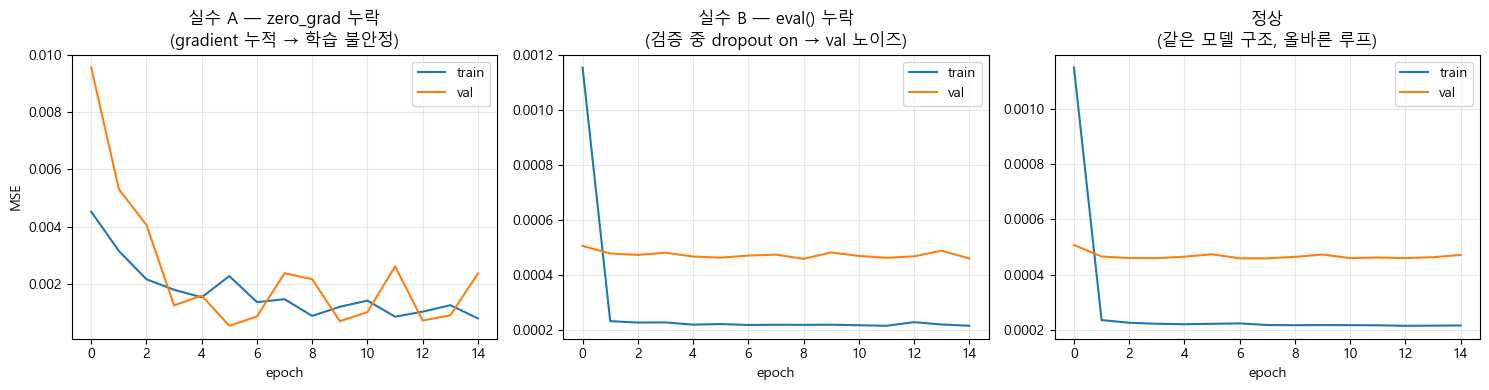

관찰 포인트:
 - A (zero_grad 누락): gradient 가 배치마다 누적되어 사실상 매우 큰 lr 로 학습한 효과 → loss 가 불안정하게 요동
 - B (eval 누락)     : val 단계에서도 dropout 랜덤이 켜져 val_loss 가 epoch 마다 진동, 평가 신뢰성 없음
 - 두 실수 모두 "돌아는 가지만" 모델 품질을 망가뜨림 — 에러 메시지가 없어서 더 위험


In [11]:
# ---------------------------------------------------------------------
# 시각화 — 3조건 비교
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

axes[0].plot(hist_skip_zero['train_loss'], label='train')
axes[0].plot(hist_skip_zero['val_loss'],   label='val')
axes[0].set_title('실수 A — zero_grad 누락\n(gradient 누적 → 학습 불안정)')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('MSE')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_skip_eval['train_loss'], label='train')
axes[1].plot(hist_skip_eval['val_loss'],   label='val')
axes[1].set_title('실수 B — eval() 누락\n(검증 중 dropout on → val 노이즈)')
axes[1].set_xlabel('epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(hist_ok['train_loss'], label='train')
axes[2].plot(hist_ok['val_loss'],   label='val')
axes[2].set_title('정상\n(같은 모델 구조, 올바른 루프)')
axes[2].set_xlabel('epoch')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print('관찰 포인트:')
print(' - A (zero_grad 누락): gradient 가 배치마다 누적되어 사실상 매우 큰 lr 로 학습한 효과 → loss 가 불안정하게 요동')
print(' - B (eval 누락)     : val 단계에서도 dropout 랜덤이 켜져 val_loss 가 epoch 마다 진동, 평가 신뢰성 없음')
print(' - 두 실수 모두 "돌아는 가지만" 모델 품질을 망가뜨림 — 에러 메시지가 없어서 더 위험')

## §5. Gradient Clipping 유무 비교 — 이론 §12

시퀀스 모델의 gradient 는 $W_h$ 의 반복 곱 때문에 **폭발하기 쉽습니다**. `clip_grad_norm_` 은 전체 파라미터의 norm 이 임계값을 넘으면 전체를 같은 비율로 축소 → **방향 유지, 크기만 제한**.

### 실험 설계
- 의도적으로 **공격적인 lr (5e-2)** 로 학습시켜 폭발을 유발
- clip ON (max_norm=1.0) vs clip OFF 비교
- NaN 발생 여부, 학습 안정성 관찰

In [12]:
# ---------------------------------------------------------------------
# Clipping OFF 먼저 — lr 5e-2 라는 공격적 조건
# ---------------------------------------------------------------------
torch.manual_seed(SEED)
model_noclip = LSTMRegressor(1, 64, 1, 0.0).to(device)
hist_noclip, best_noclip, _ = train_standard(
    model_noclip, train_loader, val_loader, device,
    max_epochs=15, lr=5e-2, weight_decay=0.0,
    clip_grad=None,           # ← clipping 없음
    scheduler_kind='none',
    verbose=False,
)
# NaN 체크 — 이론 §12 에서 언급한 실패 모드
train_losses = np.array(hist_noclip['train_loss'])
n_nan = int(np.isnan(train_losses).sum())
print(f'[clip OFF] best val MSE = {best_noclip:.6f}')
print(f'[clip OFF] NaN 발생 epoch 수: {n_nan} / {len(train_losses)}')

# ---------------------------------------------------------------------
# Clipping ON — 같은 lr
# ---------------------------------------------------------------------
torch.manual_seed(SEED)
model_clip = LSTMRegressor(1, 64, 1, 0.0).to(device)
hist_clip, best_clip, _ = train_standard(
    model_clip, train_loader, val_loader, device,
    max_epochs=15, lr=5e-2, weight_decay=0.0,
    clip_grad=1.0,            # ← max_norm=1.0
    scheduler_kind='none',
    verbose=False,
)
train_losses_c = np.array(hist_clip['train_loss'])
n_nan_c = int(np.isnan(train_losses_c).sum())
print(f'[clip ON ] best val MSE = {best_clip:.6f}')
print(f'[clip ON ] NaN 발생 epoch 수: {n_nan_c} / {len(train_losses_c)}')

[clip OFF] best val MSE = 0.000453
[clip OFF] NaN 발생 epoch 수: 0 / 15
[clip ON ] best val MSE = 0.000473
[clip ON ] NaN 발생 epoch 수: 0 / 15


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

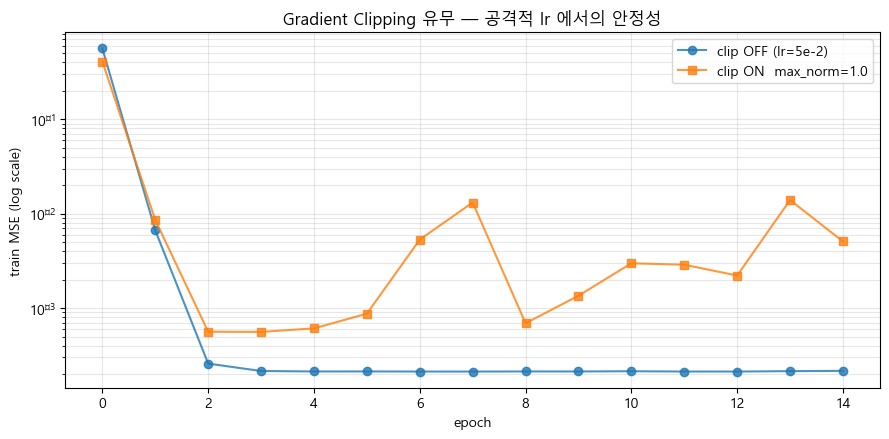

관찰: clip OFF 조건에서 초기 몇 epoch 내에 loss 가 폭주하거나 NaN 으로 깨지는 모습이 보입니다.
      clip ON 은 같은 lr 에서도 학습이 진행됩니다 — "방향 유지 / 크기 제한" 효과.


In [13]:
# ---------------------------------------------------------------------
# 시각화 — 두 조건 비교
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))
# NaN 은 plot 에서 자연스럽게 끊어져 보입니다
ax.plot(hist_noclip['train_loss'], 'o-', label='clip OFF (lr=5e-2)', alpha=0.8)
ax.plot(hist_clip['train_loss'],   's-', label='clip ON  max_norm=1.0', alpha=0.8)
ax.set_yscale('log')
ax.set_xlabel('epoch'); ax.set_ylabel('train MSE (log scale)')
ax.set_title('Gradient Clipping 유무 — 공격적 lr 에서의 안정성')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

print('관찰: clip OFF 조건에서 초기 몇 epoch 내에 loss 가 폭주하거나 NaN 으로 깨지는 모습이 보입니다.')
print('      clip ON 은 같은 lr 에서도 학습이 진행됩니다 — "방향 유지 / 크기 제한" 효과.')

## §6. LR Scheduler 3종 비교 — 이론 §13

같은 모델·같은 seed·같은 epochs 조건에서 scheduler 3종을 돌려 val_loss 수렴 차이를 관찰합니다.

| Scheduler | 정책 | 장점 | 단점 |
|---|---|---|---|
| `StepLR` | N epoch 마다 γ 배 축소 | 구현 단순, 예측 가능 | 데이터/과제 무관한 고정 스케줄 |
| `CosineAnnealingLR` | 코사인 곡선으로 부드럽게 감소 | 학습 후반 미세조정 가능 | T_max 를 잘 잡아야 함 |
| `ReduceLROnPlateau` | val_loss 가 안 떨어지면 γ 배 축소 | **데이터 반응형** — 실무 기본값 | 초기 noisy val 에서 민감 |

본 프로젝트의 Walk-Forward 와 잘 맞는 건 **ReduceLROnPlateau** 입니다 (fold 별로 최적 시점이 다르기 때문).

step    : best val MSE = 0.000452
cosine  : best val MSE = 0.000452


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


plateau : best val MSE = 0.000452


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


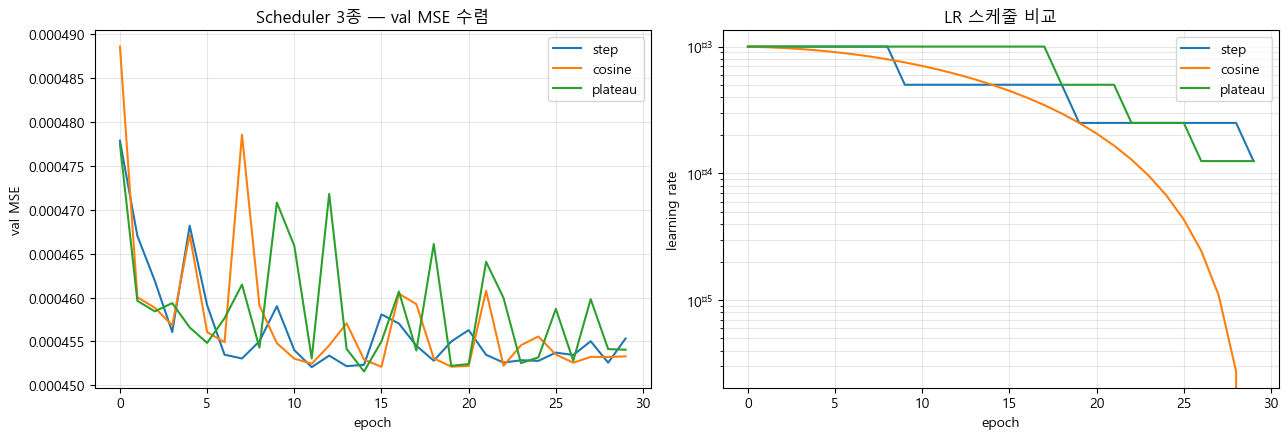

In [14]:
# ---------------------------------------------------------------------
# 3종 scheduler 각각 30 epoch 학습
# ---------------------------------------------------------------------
results = {}
for kind in ['step', 'cosine', 'plateau']:
    torch.manual_seed(SEED)
    model_k = LSTMRegressor(1, 64, 1, 0.0).to(device)
    hist_k, best_k, _ = train_standard(
        model_k, train_loader, val_loader, device,
        max_epochs=30, lr=1e-3, weight_decay=1e-4,
        clip_grad=1.0, scheduler_kind=kind,
        verbose=False,
    )
    results[kind] = hist_k
    print(f'{kind:<8}: best val MSE = {best_k:.6f}')

# ---------------------------------------------------------------------
# 시각화 — val MSE 수렴 + LR 곡선
# ---------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for kind, hist in results.items():
    ax1.plot(hist['val_loss'], label=kind)
    ax2.plot(hist['lr'],       label=kind)

ax1.set_xlabel('epoch'); ax1.set_ylabel('val MSE')
ax1.set_title('Scheduler 3종 — val MSE 수렴')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.set_xlabel('epoch'); ax2.set_ylabel('learning rate')
ax2.set_yscale('log')
ax2.set_title('LR 스케줄 비교')
ax2.legend(); ax2.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

## §7. 경량 학습 반복 함수 `train_one_individual` — 이론 §16 실전

### 왜 이 섹션이 특별한가
다음 주 **4.3 Optuna-LSTM** 은 이 함수 하나를 **n_trials = 30~50 회 반복 호출** 합니다. 즉:
- Optuna objective 는 이 함수를 얇게 감싸는 래퍼
- GA 도 같은 함수를 쓸 수 있음 (탐색 알고리즘만 다를 뿐)

### 이 함수가 만족해야 할 5가지 규약 (이론 §16.3)
1. 반환값은 **scalar float** (`best_val_loss`)
2. Best val_loss 반환 (마지막 epoch 이 아님)
3. **Minimization** 관례 — 최대화 지표는 `-지표` 반환
4. **Seed 통제** — 같은 params → 같은 결과
5. **메모리 정리** — `del + empty_cache`

### 이번 실습
5개 random hyperparam 조합으로 이 함수를 호출해 best_val_loss 를 정렬해봅니다 — Optuna 가 들어오기 전, **TPE / GA 없이도 hyperparam 선택이 얼마나 달라지는지** 체감.

In [15]:
def train_one_individual(params: dict,
                         train_loader: DataLoader,
                         val_loader: DataLoader,
                         device: torch.device,
                         seed: int = 42) -> float:
    """이론 §16.3 구조의 경량 학습 함수.
    회귀 과제용 — criterion 만 MSE 로 바꿨을 뿐, §16 설계 5규약 준수.
    반환: best_val_loss (낮을수록 좋음) — Optuna / GA 양쪽 공통 인터페이스.
    """
    # (1) 재현성
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # (2) 모델 빌드 — params 로부터
    model = LSTMRegressor(
        input_size=params.get('input_size', 1),
        hidden_size=params['hidden_size'],
        num_layers=params['num_layers'],
        dropout=params.get('dropout', 0.0),
    ).to(device)

    optimizer = optim.AdamW(model.parameters(),
                            lr=params['lr'],
                            weight_decay=params.get('weight_decay', 1e-4))
    criterion = nn.MSELoss()   # ← 회귀 (이론 §16.3 의 CrossEntropy 자리)

    max_epochs = params.get('max_epochs', 10)   # §16.1 — 경량화 핵심
    patience_limit = params.get('patience', 3)

    best_val = float('inf')
    patience_counter = 0

    for _ in range(max_epochs):
        # train
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        # validate
        model.eval()
        val_sum, val_n = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_sum += criterion(model(xb), yb).item() * xb.size(0)
                val_n   += xb.size(0)
        val_loss = val_sum / val_n
        # early stop (§16.2)
        if val_loss < best_val:
            best_val = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience_limit:
                break

    # (5) 메모리 정리 — §16.4
    del model, optimizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return best_val

In [16]:
# ---------------------------------------------------------------------
# 5개 random hyperparam 조합 생성 후 fitness 비교
# ---------------------------------------------------------------------
rng = np.random.default_rng(SEED)

def sample_params(rng):
    """이론 프로젝트 메모리 (v2.4) 의 탐색 공간과 동일."""
    return {
        'input_size':   1,
        'hidden_size':  int(rng.choice([32, 64, 128, 256])),
        'num_layers':   int(rng.integers(1, 4)),       # 1~3
        'dropout':      float(rng.uniform(0.0, 0.5)),
        'lr':           float(10 ** rng.uniform(-4, np.log10(5e-3))),   # 1e-4 ~ 5e-3 log-scale
        'weight_decay': 1e-4,
        'max_epochs':   10,
        'patience':     3,
    }

trials = []
for i in range(5):
    params = sample_params(rng)
    val_loss = train_one_individual(params, train_loader, val_loader, device, seed=SEED)
    trials.append({'trial': i, **params, 'val_loss': val_loss})
    print(f'trial {i}: H={params["hidden_size"]:<3} L={params["num_layers"]} '
          f'drop={params["dropout"]:.2f} lr={params["lr"]:.1e} '
          f'→ val_loss={val_loss:.6f}')

trials_df = pd.DataFrame(trials).sort_values('val_loss').reset_index(drop=True)
print('\n정렬된 결과 (낮은 val_loss 순 = Optuna 가 좋아할 순):')
trials_df[['hidden_size', 'num_layers', 'dropout', 'lr', 'val_loss']]

trial 0: H=32  L=3 drop=0.22 lr=2.9e-03 → val_loss=0.000461
trial 1: H=32  L=3 drop=0.05 lr=4.5e-03 → val_loss=0.000462
trial 2: H=128 L=3 drop=0.39 lr=1.7e-04 → val_loss=0.000461
trial 3: H=256 L=2 drop=0.19 lr=3.8e-03 → val_loss=0.000455
trial 4: H=256 L=2 drop=0.41 lr=5.7e-04 → val_loss=0.000461

정렬된 결과 (낮은 val_loss 순 = Optuna 가 좋아할 순):


,hidden_size,num_layers,dropout,lr,val_loss
0,256,2,0.185399,0.003754,0.000455
1,32,3,0.219439,0.002876,0.000461
2,128,3,0.393032,0.000165,0.000461
3,256,2,0.411381,0.000567,0.000461
4,32,3,0.047089,0.004545,0.000462


In [17]:
# ---------------------------------------------------------------------
# 관찰 — hyperparam 이 val_loss 에 얼마나 영향을 주는가
# ---------------------------------------------------------------------
print(f'val_loss 최소 : {trials_df["val_loss"].min():.6f}')
print(f'val_loss 최대 : {trials_df["val_loss"].max():.6f}')
print(f'최대/최소 비율: {trials_df["val_loss"].max() / trials_df["val_loss"].min():.2f}x')
print()
print('교훈:')
print(' - 같은 데이터·같은 함수·같은 seed 에서도 hyperparam 에 따라 성능이 크게 달라집니다.')
print(' - 그래서 **체계적 탐색** (Optuna / GA / Random Search) 이 필요합니다.')
print(' - 4.3 에서는 이 `train_one_individual` 을 Optuna objective 로 5줄 래퍼만 감싸서')
print('   TPE sampler + MedianPruner 로 30~50회 지능 탐색을 수행할 예정입니다.')

val_loss 최소 : 0.000455
val_loss 최대 : 0.000462
최대/최소 비율: 1.02x

교훈:
 - 같은 데이터·같은 함수·같은 seed 에서도 hyperparam 에 따라 성능이 크게 달라집니다.
 - 그래서 **체계적 탐색** (Optuna / GA / Random Search) 이 필요합니다.
 - 4.3 에서는 이 `train_one_individual` 을 Optuna objective 로 5줄 래퍼만 감싸서
   TPE sampler + MedianPruner 로 30~50회 지능 탐색을 수행할 예정입니다.


## §8. MSE vs Huber Loss — outlier 민감도 비교 (이론 §10 확장)

### 왜 Huber 인가
금융 수익률에는 **급등락 (점프)** 같은 outlier 가 자연스럽게 존재합니다. MSE 는 잔차를 **제곱** 하므로 outlier 하나가 loss 의 대부분을 차지 → 모델이 **outlier 에 과적합**.

Huber Loss 는 잔차가 작을 땐 MSE, 클 땐 L1 처럼 선형이 되어 outlier 의 영향력을 제한합니다:

$$L_\delta(r) = \begin{cases} \tfrac{1}{2}r^2 & |r| \le \delta \\ \delta(|r| - \tfrac{1}{2}\delta) & |r| > \delta \end{cases}$$

COL-BL 에서 Huber 를 **옵션으로 두는 근거** — 수익률 outlier 에 대한 방어입니다.

### 실험 설계
- train 데이터의 1% 에 5σ outlier 를 임의로 주입
- 동일 모델을 MSE / Huber(δ=1.0) 로 학습 → val MSE 비교

In [18]:
# ---------------------------------------------------------------------
# outlier 주입된 train 데이터 만들기
# ---------------------------------------------------------------------
rng2 = np.random.default_rng(SEED + 1)
y_train_noisy = y_train.copy()
n_outliers = max(1, int(0.01 * len(y_train_noisy)))  # 1%
outlier_idx = rng2.choice(len(y_train_noisy), size=n_outliers, replace=False)

sigma = y_train.std()
# +/- 5σ outlier 주입
y_train_noisy[outlier_idx] = (rng2.choice([-1, 1], size=n_outliers) * 5 * sigma).astype(np.float32)

print(f'원본 train std        : {y_train.std():.6f}')
print(f'outlier 주입 후 train std: {y_train_noisy.std():.6f}')
print(f'주입된 outlier 개수: {n_outliers} / {len(y_train_noisy)}')

train_loader_noisy = make_loader(X_train, y_train_noisy, BATCH_SIZE, shuffle=True)

원본 train std        : 0.014554
outlier 주입 후 train std: 0.016227
주입된 outlier 개수: 22 / 2203


In [19]:
# ---------------------------------------------------------------------
# train_one_individual 의 criterion 만 바꿔서 실험할 수 있도록 loss 파라미터화
# ---------------------------------------------------------------------
def train_with_loss(loss_fn: nn.Module,
                    tl: DataLoader,
                    vl: DataLoader,
                    max_epochs: int = 15,
                    seed: int = SEED) -> dict:
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = LSTMRegressor(1, 64, 1, 0.0).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    mse_metric = nn.MSELoss()

    history = {'val_mse': []}
    best_val = float('inf')
    for _ in range(max_epochs):
        model.train()
        for xb, yb in tl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)         # ← 학습 loss (MSE 또는 Huber)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        s, n = 0.0, 0
        with torch.no_grad():
            for xb, yb in vl:
                xb, yb = xb.to(device), yb.to(device)
                s += mse_metric(model(xb), yb).item() * xb.size(0)   # ← 평가는 항상 MSE 로 (공정 비교)
                n += xb.size(0)
        val_mse = s / n
        history['val_mse'].append(val_mse)
        best_val = min(best_val, val_mse)

    del model, optimizer
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return {'history': history, 'best_val_mse': best_val}


# MSE 학습 (outlier 주입된 train)
res_mse   = train_with_loss(nn.MSELoss(),                 train_loader_noisy, val_loader)
# Huber 학습 (outlier 주입된 train, delta=1.0 — 수익률 스케일 대비 아주 넉넉한 값)
res_huber = train_with_loss(nn.HuberLoss(delta=1.0),      train_loader_noisy, val_loader)
# 참고: outlier 없는 정상 train + MSE (이상 비교 목적)
res_clean = train_with_loss(nn.MSELoss(),                 train_loader,       val_loader)

print(f'[MSE   + outlier train ] best val MSE = {res_mse["best_val_mse"]:.6f}')
print(f'[Huber + outlier train ] best val MSE = {res_huber["best_val_mse"]:.6f}')
print(f'[MSE   + clean   train ] best val MSE = {res_clean["best_val_mse"]:.6f}  (reference)')

[MSE   + outlier train ] best val MSE = 0.000452
[Huber + outlier train ] best val MSE = 0.000452
[MSE   + clean   train ] best val MSE = 0.000453  (reference)


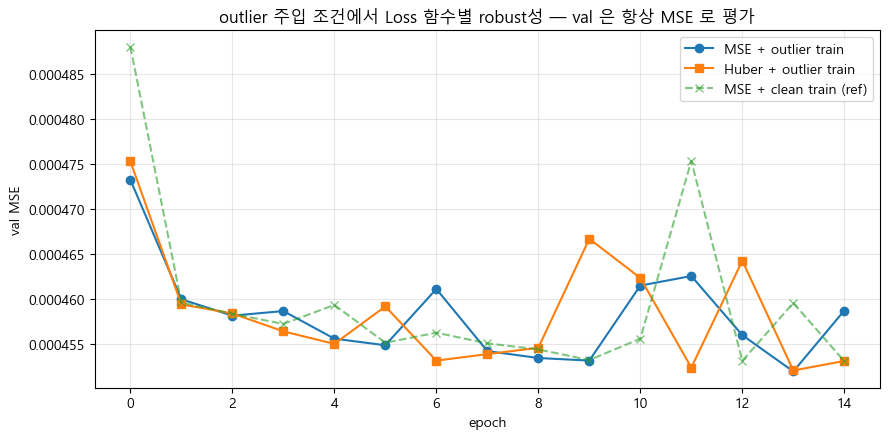

관찰 포인트:
 - outlier 를 주입하면 MSE 학습은 outlier 에 끌려다녀 val MSE 가 불안정
 - Huber(δ=1.0) 는 outlier 잔차를 선형으로 제한 → clean 기준선에 더 가깝게 수렴
 - COL-BL 에서는 수익률 점프가 자연스럽게 있으므로 Huber 를 "옵션"으로 두는 것이 정당


In [20]:
# ---------------------------------------------------------------------
# 시각화
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(res_mse['history']['val_mse'],   'o-', label='MSE + outlier train')
ax.plot(res_huber['history']['val_mse'], 's-', label='Huber + outlier train')
ax.plot(res_clean['history']['val_mse'], 'x--', label='MSE + clean train (ref)', alpha=0.6)
ax.set_xlabel('epoch'); ax.set_ylabel('val MSE')
ax.set_title('outlier 주입 조건에서 Loss 함수별 robust성 — val 은 항상 MSE 로 평가')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('관찰 포인트:')
print(' - outlier 를 주입하면 MSE 학습은 outlier 에 끌려다녀 val MSE 가 불안정')
print(' - Huber(δ=1.0) 는 outlier 잔차를 선형으로 제한 → clean 기준선에 더 가깝게 수렴')
print(' - COL-BL 에서는 수익률 점프가 자연스럽게 있으므로 Huber 를 "옵션"으로 두는 것이 정당')

## 마무리 — 이번 노트북에서 검증한 것

| 이론 주제 | 이 노트북 결과 | 비고 |
|---|---|---|
| 표준 학습 루프 4단계 | §3 baseline 정상 수렴 | — |
| zero_grad / eval() 누락 | §4 에서 두 실수 모두 조용히 성능 망가짐 재현 | 에러가 안 나므로 더 위험 |
| Gradient Clipping | §5 에서 lr=5e-2 조건 clip OFF → loss 폭주 / clip ON → 학습 진행 | 시퀀스 모델 필수 |
| LR Scheduler 3종 | §6 에서 Plateau 가 val 반응형으로 가장 안정 | Walk-Forward 와 궁합 좋음 |
| 경량 학습 함수 `train_one_individual` | §7 에서 5 random 조합 → 최저/최고 val_loss 수배 차이 | **다음 주 Optuna objective 로 그대로 재사용** |
| MSE vs Huber | §8 에서 outlier 1% 주입 시 Huber 가 더 안정 | COL-BL Huber 옵션의 근거 |

### 다음 토픽 — 3.5 학습 안정화 + 정규화

이번 노트북은 **학습 루프의 골격** 에 집중했습니다. 3.5 에서는 **LSTM 계열 특유의 안정화 기법** 을 다룹니다:
- LayerNorm vs BatchNorm (시퀀스 모델이 왜 LayerNorm 을 선호하는가)
- Variational Dropout (Gal & Ghahramani) — LSTM 에서 올바른 dropout 적용
- Zoneout — hidden/cell state 의 확률적 보존
- weight_decay vs L2 regularization 의 미묘한 차이
- 본 프로젝트 (COL-BL) 의 과적합 위험 정량화

---
**이 노트북의 핵심 산출물**: `train_one_individual(params) → best_val_loss` 함수.
4.3 Optuna-LSTM 실습에서 이 함수를 `objective(trial)` 로 얇게 감쌀 것입니다 — 이론 §16.3 말미 "Optuna objective 로의 자연스러운 변환" 예시가 그대로 적용됩니다.